In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)
print(iris.feature_names)
print(iris.target_names)

(150, 4)
(150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(150, 2)


In [6]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["target"] = y

pca_df.head()

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


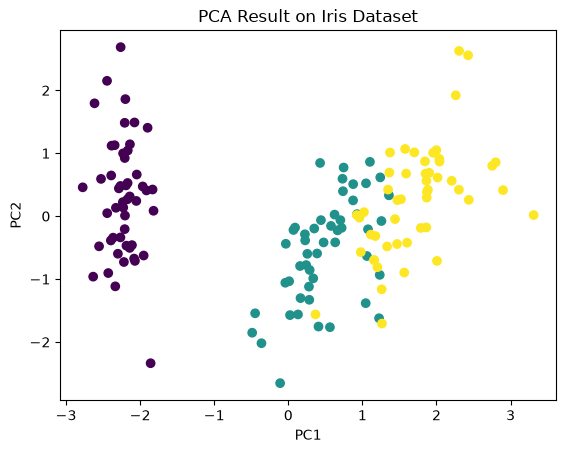

In [7]:
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["target"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result on Iris Dataset")
plt.show()

In [8]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [9]:
print(pca.explained_variance_ratio_.sum())

0.9581320720000166


In [10]:
pca_3 = PCA(n_components=3)

X_pca_3 = pca_3.fit_transform(X_scaled)

print(X_pca_3.shape)
print(pca_3.explained_variance_ratio_)
print("累计保留信息比例：", pca_3.explained_variance_ratio_.sum())

(150, 3)
[0.72962445 0.22850762 0.03668922]
累计保留信息比例： 0.9948212908928454


In [11]:
pca_all = PCA()

pca_all.fit(X_scaled)

print(pca_all.explained_variance_ratio_)

[0.72962445 0.22850762 0.03668922 0.00517871]


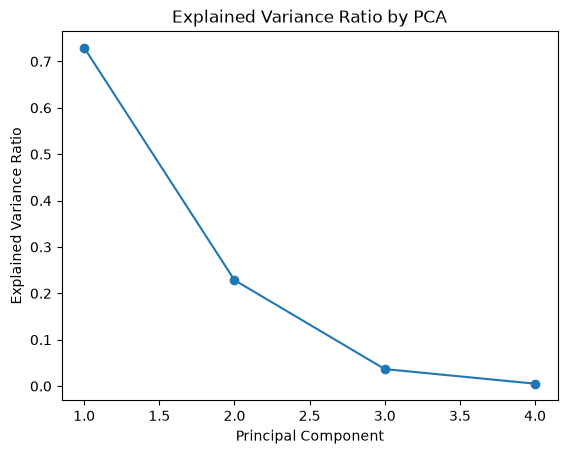

In [12]:
plt.plot(
    range(1, 5),
    pca_all.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio by PCA")
plt.show()

In [13]:
import numpy as np

cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)

print(cumulative_variance)

[0.72962445 0.95813207 0.99482129 1.        ]


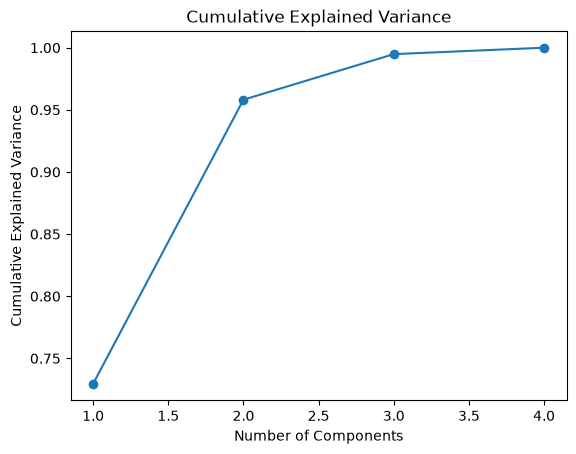

In [14]:
plt.plot(
    range(1, 5),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

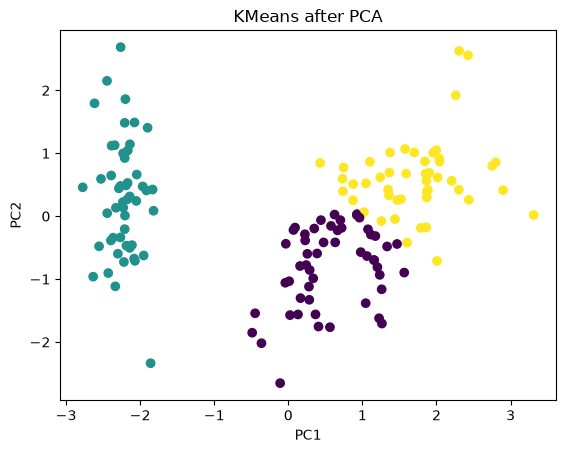

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans after PCA")
plt.show()